# Lab: Comparing Distributions Across Groups

New York City residents can use 311 to report potholes, cave-ins, failed street repairs, and other street conditions. Comparing the daily volume of these requests can help a city describe where reported demand for street-condition services was greatest.

Use the reproducible analysis workflow:

1. **Question**
2. **Data**
3. **Operation**
4. **Check**
5. **Evidence**
6. **Conclusion**
7. **Limitation**


## Learning goals

- use Pandas datetime and string methods to prepare categories;
- use `groupby()`, `.size()`, and `reset_index()` to create daily counts;
- summarize a quantitative feature within groups;
- compare distributions with histograms, box plots, and violin plots;
- interpret center, spread, shape, overlap, and unusual values; and
- distinguish reported request volume from the underlying number of street problems.


## Using AI tools responsibly

You may use an AI tool to ask questions, debug code, or receive feedback. You remain responsible for understanding and checking every submitted response against the notebook output.

At the end, disclose whether you used AI. If you did, describe one suggestion you evaluated and what you accepted, modified, or rejected. If you did not, state that clearly.


## Dataset

The teaching file contains NYC 311 service requests created during 2025 with the complaint type `Street Condition`. Rows assigned to an unspecified borough were excluded. Each row represents one service request, not one unique street problem.

| Feature | Description |
| --- | --- |
| `request_id` | Identifier assigned to the 311 service request |
| `created_date` | Date and time when 311 created the request |
| `borough` | Borough assigned to the request |
| `descriptor` | More specific kind of street condition |

The file was downloaded from NYC Open Data on August 13, 2026. See `data/README.md` for provenance and preparation details.


# Guided analysis

## Step 1: Question

> **How did the daily number of reported street-condition requests differ across New York City's five boroughs in 2025?**


## Step 2: Data

### Import the libraries

Import Pandas, Matplotlib's `pyplot`, and Seaborn using their conventional aliases.


In [1]:
# Write your code here.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Read the data

Read `data/nyc_311_street_conditions_2025.csv` into a DataFrame named `requests`. Use `parse_dates=["created_date"]` so Pandas converts the CSV's text timestamps into datetime values while loading the file.


In [7]:
# Write your code here.
requests = pd.read_csv(
    "nyc_311_street_conditions_2025.csv",
    parse_dates=["created_date"]
)

### Preview the data

Display the first and last five rows.


In [9]:
# Write your code here.
display(requests.head())
display(requests.tail())

,request_id,created_date,borough,descriptor
0,63575321,2025-01-01 02:27:33,BROOKLYN,Pothole
1,63585580,2025-01-01 02:31:08,QUEENS,Pothole
2,63590681,2025-01-01 02:39:44,BROOKLYN,Dumpster - Construction Waste
3,63580421,2025-01-01 02:55:52,QUEENS,Pothole
4,63605103,2025-01-01 04:20:00,BROOKLYN,Wear & Tear


,request_id,created_date,borough,descriptor
70193,67353473,2025-12-31 22:26:49,STATEN ISLAND,Pothole
70194,67346881,2025-12-31 22:27:34,STATEN ISLAND,Pothole
70195,67352385,2025-12-31 22:28:43,STATEN ISLAND,Cave-in
70196,67350032,2025-12-31 22:53:19,MANHATTAN,Defective Hardware
70197,67348685,2025-12-31 23:39:14,QUEENS,Pothole


### Inspect the DataFrame

Display its stored data types and missing-value counts.


In [10]:
# Write your code here.
requests.info()
requests.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70198 entries, 0 to 70197
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   request_id    70198 non-null  int64         
 1   created_date  70198 non-null  datetime64[ns]
 2   borough       70198 non-null  object        
 3   descriptor    70198 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 2.1+ MB


request_id      0
created_date    0
borough         0
descriptor      0
dtype: int64

**Complete the table using the data dictionary and your inspection results.** Classify each feature as categorical, quantitative, or temporal.

| Feature | Data type | Data storage type | Missing values |
| --- | --- | --- | ---: |
| `request_id` | Categorical | int64 | 0 |
| `created_date` | Temporal | datetime64[ns] | 0 |
| `borough` | Categorical | object | 0 |
| `descriptor` | Categorical | object | 0 |


**What does one row represent?**

Your answer: One row represents one 311 street-condition service request.


### Predict


**Which borough do you predict will have the greatest typical number of reported street-condition requests per day? What informed your prediction?**

Your answer: I predict Brooklyn because it is a large borough, I also live in nyc so I think Brooklyn. 


## Step 3: Operation


### Make the borough names human-readable

The source stores borough names in all capital letters. **Title case** capitalizes the first letter of each word and writes the remaining letters in lowercase. For example, `STATEN ISLAND` becomes `Staten Island`.

Use `.str.title()` to convert every value in `requests["borough"]` to title case and save the result back into the same feature.


In [12]:
# Write your code here.
requests["borough"] = requests["borough"].str.title()

**What roles do `.str` and `.title()` play in this statement?**

Your answer: .str lets Pandas use string methods on the borough column, and .title() changes each borough name to desired title case.


### Create a calendar date

Create `requests["date"]` with `requests["created_date"].dt.normalize()`. The `.dt` accessor opens Pandas' datetime tools, and `.normalize()` sets the time in every value to midnight while preserving its calendar date.


In [15]:
# Write your code here.
requests["date"] = requests["created_date"].dt.normalize()
requests[["created_date", "date"]].head()

,created_date,date
0,2025-01-01 02:27:33,2025-01-01
1,2025-01-01 02:31:08,2025-01-01
2,2025-01-01 02:39:44,2025-01-01
3,2025-01-01 02:55:52,2025-01-01
4,2025-01-01 04:20:00,2025-01-01


### Count requests for each borough and date

Create a DataFrame named `daily_requests` with this sequence:

1. group `requests` by `date` and `borough`;
2. use `.size()` to count rows in every group; and
3. use `.reset_index(name="request_count")` to return a DataFrame whose count column is named `request_count`.

Display the first five rows.


In [16]:
# Write your code here.
daily_requests = (
    requests.groupby(["date", "borough"])
    .size()
    .reset_index(name="request_count")
)
daily_requests.head()

,date,borough,request_count
0,2025-01-01,Bronx,33
1,2025-01-01,Brooklyn,64
2,2025-01-01,Manhattan,14
3,2025-01-01,Queens,70
4,2025-01-01,Staten Island,8


**What does one row of `daily_requests` represent? How is that different from one row of `requests`?**

Your answer: One row of daily_requests represents the number of requests for one borough on one day. One row of requests represents one individual 311 service request.


**Why did we remove the time before grouping and counting the requests?** As a hint, try repeating the calculation with `created_date` in place of `date` and inspect the result.

Your answer: We removed the time so all requests from the same day would be grouped together to make it more precise.


### Set the borough order

Create `borough_order` containing the five borough names in alphabetical order.


In [17]:
# Write your code here.
borough_order = [
    "Bronx",
    "Brooklyn",
    "Manhattan",
    "Queens",
    "Staten Island"
]

### Calculate the mean daily request count

Create `borough_summary` by grouping `daily_requests` by `borough`, selecting `request_count`, calculating the mean, and using `.reindex(borough_order)`.


In [18]:
# Write your code here.
borough_summary = (
    daily_requests.groupby("borough")["request_count"]
    .mean()
    .reindex(borough_order)
)
borough_summary

borough
Bronx            19.060274
Brooklyn         50.345205
Manhattan        33.936986
Queens           71.180822
Staten Island    17.800000
Name: request_count, dtype: float64

**Why is comparing only these means incomplete?**

Your answer: The means only show the average. They do not show anything specific in each borough's daily request counts.


## Step 4: Check


### Check borough-date coverage

Count the number of rows for each borough in `daily_requests`, then use `.reindex(borough_order)`.


In [19]:
# Write your code here.
daily_requests.groupby("borough").size().reindex(borough_order)

borough
Bronx            365
Brooklyn         365
Manhattan        365
Queens           365
Staten Island    365
dtype: int64

**Does every borough have a count for all 365 dates?**

Your answer: Yes, each borough has a count on all 365 dates. 


**What would it mean if one or more boroughs had a count of fewer than 365 rows?**

Your answer: It would mean that that Burrow was missing dates from the 365 day count. 


### Check the calculated data

Display missing-value counts for `date`, `borough`, and `request_count`. Then use `.describe()` to summarize `request_count` within each borough and put the boroughs in `borough_order`.


In [22]:
# Write your code here.
display(daily_requests[["date", "borough", "request_count"]].isnull().sum())
daily_requests.groupby("borough")["request_count"].describe().reindex(borough_order)

date             0
borough          0
request_count    0
dtype: int64

,count,mean,std,min,25%,50%,75%,max
borough,,,,,,,,
Bronx,365.0,19.060274,9.238398,1.0,12.0,18.0,25.0,48.0
Brooklyn,365.0,50.345205,21.132529,6.0,33.0,51.0,65.0,113.0
Manhattan,365.0,33.936986,14.683432,2.0,23.0,33.0,43.0,91.0
Queens,365.0,71.180822,30.362103,11.0,47.0,70.0,89.0,215.0
Staten Island,365.0,17.800000,10.095206,1.0,10.0,17.0,24.0,66.0


**Are any calculated values missing or impossible?**

Your answer: No, there are no missing values, and the request counts look possible.


**Would a zero necessarily be impossible in another 311 dataset?**

Your answer: No. A zero could mean that no requests were reported for a borough on that day.


## Step 5: Evidence


### Create overlapping histograms

Use `sns.histplot()` with:

- `data=daily_requests`;
- `x="request_count"`;
- `hue="borough"` and `hue_order=borough_order`;
- `element="step"`;
- layered histograms;
- `alpha=0.45`; and
- the `"deep"` palette.

Capitalize the legend title and add a question-focused title and descriptive axis labels. Label the y-axis `Number of days`.


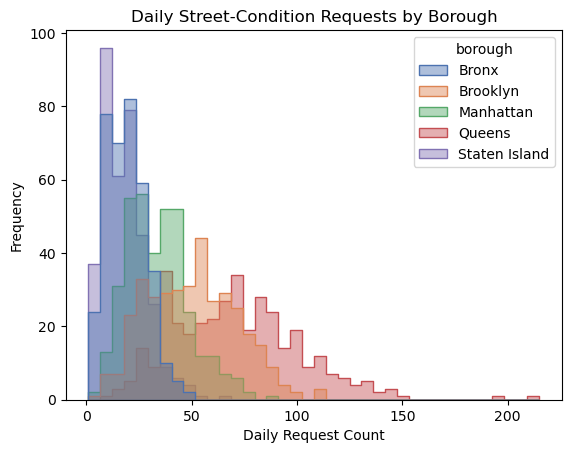

In [23]:
# Write your code here.
sns.histplot(
    data=daily_requests,
    x="request_count",
    hue="borough",
    hue_order=borough_order,
    element="step",
    multiple="layer",
    alpha=0.45,
    palette="deep"
)

plt.title("Daily Street-Condition Requests by Borough")
plt.xlabel("Daily Request Count")
plt.ylabel("Frequency")
plt.show()

**What does the histogram reveal, and what makes the boroughs easy or difficult to compare?**

Your answer: Queens and Brooklyn have higher daily request counts, while Bronx and Staten Island are lower. The overlap makes some boroughs harder to compare.


### Create a box plot

Put `request_count` on the x-axis and `borough` on the y-axis. Use `borough_order`, the named color `"mediumseagreen"`, and descriptive labels.


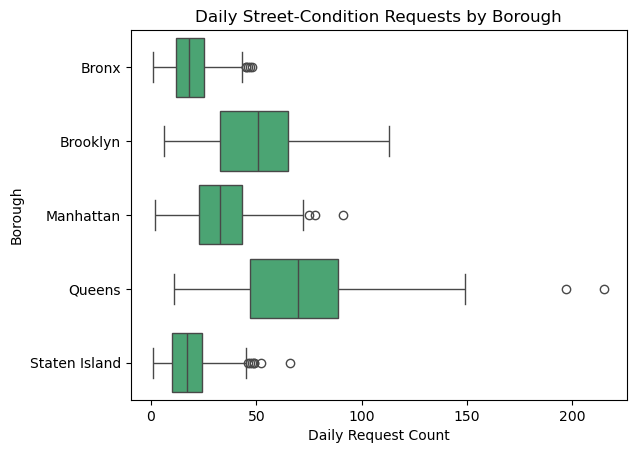

In [24]:
# Write your code here.
sns.boxplot(
    data=daily_requests,
    x="request_count",
    y="borough",
    order=borough_order,
    color="mediumseagreen"
)

plt.title("Daily Street-Condition Requests by Borough")
plt.xlabel("Daily Request Count")
plt.ylabel("Borough")
plt.show()

**What differences among boroughs are easier to see in the box plot than in the histogram?**

Your answer: The box plot makes it easier to compare the medians and values for each borough.


### Create a violin plot

Use the same x feature, y feature, and order. Change only the plot color to `"mediumpurple"` in addition to the required data mappings and order.


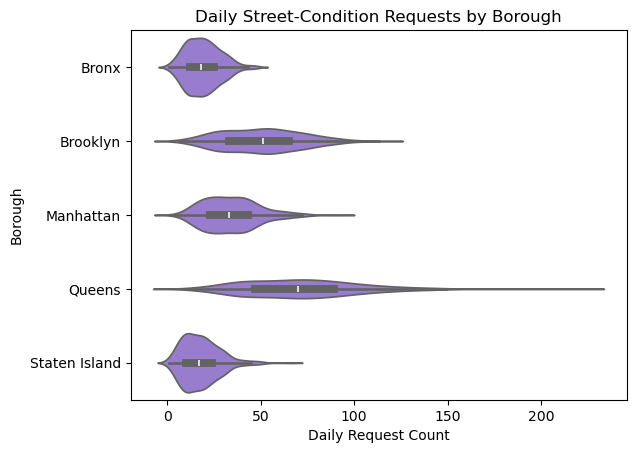

In [25]:
# Write your code here.
sns.violinplot(
    data=daily_requests,
    x="request_count",
    y="borough",
    order=borough_order,
    color="mediumpurple"
)

plt.title("Daily Street-Condition Requests by Borough")
plt.xlabel("Daily Request Count")
plt.ylabel("Borough")
plt.show()

**What does the violin plot add to the comparison?**

Your answer: Violen plot makes it really easy to see the shape and spread of daily counts for each borough. 


**Which of the three figures most clearly compares daily request counts among boroughs? Explain your choice.**

Your answer: I would choose the boxplot because it compares the medians and the spreads the easiest. 


## Step 6: Conclusion


**What conclusion about borough differences is supported by the 2025 data?**

Your answer: Queens had the highest typical daily request count. Staten Island and Bronx had the lowest. 


## Step 7: Limitation


**Why do these request counts not directly measure the number of street problems or borough performance?**

Your answer: The counts are only 311 requests. They dont show every stree problem across all boroughs. 


# Your own analysis

Develop a new research question using the 311 data. Your question must compare a **quantitative feature across categorical groups**. You will probably need to calculate the quantitative feature from the original request records.

Possible grouping features include `descriptor`, month, or day of the week. You may use another meaningful categorical feature that you can create and explain.


## Step 1: Question


**Write a research question that compares a quantitative feature across categorical groups.**

Your answer: How does the daily number of 311 street-condition requests differ by descriptor?


## Step 2: Data


**Which original features will you use, and what will each row of your calculated DataFrame represent?**

Your answer: I will use created_date and descriptor. Each row will represent the number of requests for one descriptor on one day.


## Step 3: Operation

Prepare the grouping feature, calculate the quantitative feature, and save the resulting DataFrame with a meaningful name.


In [26]:
# Write your code here.
descriptor_daily = (
    requests.groupby(["date", "descriptor"])
    .size()
    .reset_index(name="request_count")
)

descriptor_daily.head()

,date,descriptor,request_count
0,2025-01-01,Blocked - Construction,2
1,2025-01-01,Cave-in,9
2,2025-01-01,Defective Hardware,7
3,2025-01-01,Dumpster - Construction Waste,2
4,2025-01-01,Failed Street Repair,4


**Briefly explain how your code produced the quantitative feature and comparison groups.**

Your answer: I grouped the data by date and descriptor, then counted the number of requests in each group. 

## Step 4: Check

Check the calculated data for missing or impossible values, confirm that the intended groups are present, and use an appropriate numerical summary to inspect the distributions.


In [27]:
# Write your code here.
display(descriptor_daily.isnull().sum())
descriptor_daily.groupby("descriptor")["request_count"].describe()

date             0
descriptor       0
request_count    0
dtype: int64

,count,mean,std,min,25%,50%,75%,max
descriptor,,,,,,,,
Blocked - Construction,363.0,11.691460,6.322249,1.0,7.0,11.0,16.00,37.0
Cave-in,365.0,26.413699,16.324872,2.0,13.0,23.0,36.00,79.0
Crash Cushion Defect,140.0,1.607143,1.407567,1.0,1.0,1.0,2.00,15.0
Defacement,10.0,2.000000,2.000000,1.0,1.0,1.0,1.75,7.0
Defective Hardware,365.0,15.041096,5.741306,3.0,11.0,15.0,19.00,41.0
Depression Maintenance,23.0,1.304348,0.558796,1.0,1.0,1.0,1.50,3.0
Dumpster - Construction Waste,280.0,2.085714,1.255729,1.0,1.0,2.0,3.00,7.0
Failed Street Repair,363.0,9.606061,5.033223,1.0,5.0,9.0,13.00,29.0
Guard Rail - Street,82.0,1.292683,0.484011,1.0,1.0,1.0,2.00,3.0


**What did your checks establish?**

Your answer: The checks showed there were no missing values, the descriptor groups were present, and the request counts looked possible.


## Step 5: Evidence

Create a histogram, box plot, or violin plot that directly addresses your question. Include a clear title and descriptive axis labels.


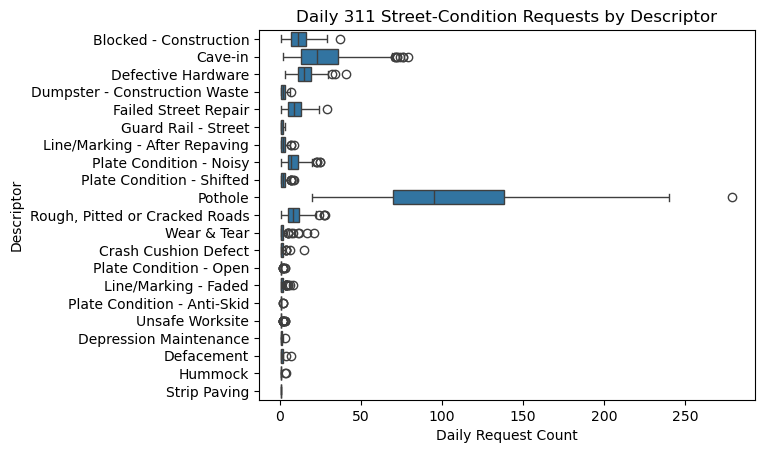

In [28]:
# Write your code here.
sns.boxplot(
    data=descriptor_daily,
    x="request_count",
    y="descriptor"
)

plt.title("Daily 311 Street-Condition Requests by Descriptor")
plt.xlabel("Daily Request Count")
plt.ylabel("Descriptor")
plt.show()

**What pattern in the figure provides the strongest evidence for your answer?**

Your answer: Pothole requests are much higher than the other descriptor groups on most days.


## Step 6: Conclusion


**State one conclusion that directly answers your research question.**

Your answer: Pothole requests had the highest daily request counts compared with the other descriptor groups.


## Step 7: Limitation


**State one important limitation on how your result should be interpreted.**

Your answer: The data only shows reported 311 requests, so it may not represent every street problem.


## AI-use reflection


State whether you used an AI tool. If you did, identify one suggestion you checked and explain what you accepted, modified, or rejected. If you did not, state that clearly.

Your answer:I used ChatGPT to check a few code steps and make sure my results matched the notebook output.


## Submission checklist

- Run every code cell from top to bottom.
- Use all requested object and feature names.
- Complete every written-response cell.
- Check that numerical claims match the output.
- Use named colors and audience-friendly labels.
- Compare center, spread, shape, overlap, and unusual values.
- Distinguish reported request volume from actual street conditions or city performance.
- Complete the AI-use reflection.
